In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import sys
sys.path.append("/home/z5297792/UNSW-MRes/MRes/modules") 
from utils import unit_det, psi_params, axis_ratio_from_Q


In [2]:
def latte(xi, yi, ui, vi):
    from scipy.optimize import least_squares
    xi, yi, ui, vi = map(lambda a: np.asarray(a, float), (xi, yi, ui, vi))
    m = np.isfinite(xi) & np.isfinite(yi) & np.isfinite(ui) & np.isfinite(vi)
    x, y, u_i, v_i = xi[m], yi[m], ui[m], vi[m]
    n = x.size
    if n < 3:
        return np.nan, np.nan, np.nan, np.full((2,2), np.nan), np.nan, np.nan

    p0 = np.array([x.mean(), y.mean(), 1., 0., 1.])  # xc,yc,Oq11,Oq12,Oq22

    def fun(p):
        xc,yc,Oq11,Oq12,Oq22 = p
        dx, dy = x-xc, y-yc
        u = -Oq22*dy - Oq12*dx
        v =  Oq11*dx + Oq12*dy
        r = np.empty(2*n); r[:n]=u-u_i; r[n:]=v-v_i
        return r

    def jac(p):
        xc,yc,Oq11,Oq12,Oq22 = p
        dx, dy = x-xc, y-yc
        J = np.zeros((2*n,5))
        # u = -Omega*q22*(y-yc) - Omega*q12*(x-xc)
        J[:n,0], J[:n,1], J[:n,3], J[:n,4] = Oq12, Oq22, -dx, -dy
        # v = Omega*q11*(x-xc) + Omega*q12*(y-yc)
        J[n:,0], J[n:,1], J[n:,2], J[n:,3] = -Oq11, -Oq12, dx, dy
        return J

    xc,yc,Oq11,Oq12,Oq22 = least_squares(fun, p0, jac=jac).x

    dx, dy = x-xc, y-yc
    u = -Oq22*dy - Oq12*dx
    v =  Oq11*dx + Oq12*dy
    err2 = ((u-u_i)**2 + (v-v_i)**2).sum()
    tot2 = ((u_i-u_i.mean())**2 + (v_i-v_i.mean())**2).sum()
    r2 = 1 - err2/tot2 if tot2 > 0 else np.nan

    w = Oq11+Oq22
    OQ = np.array([[Oq11,Oq12],[Oq12,Oq22]])
    det = OQ[0,0]*OQ[1,1] - OQ[0,1]*OQ[1,0]
    Omega = np.sign(Oq11)*np.sqrt(abs(det))
    Q = OQ/Omega if Omega != 0 else np.full((2,2), np.nan)

    return xc, yc, w, Q, Omega#, r2

def out_core_param_fit(
    rho2, Qr, vt,
    Omega0=None, Rc0=None,
    plot=False, ax=None,
    maxfev=10000, Rc_max=1e5,
    r2_flag=False,
    rho_plot_max=None, n_curve=400,
    ci_flag=False,
    pred_flag=False,
    clr='b'
):

    from scipy.optimize import curve_fit

    rho2 = np.asarray(rho2, float)
    Qr   = np.asarray(Qr, float)
    vt   = np.asarray(vt, float)

    m = np.isfinite(rho2) & np.isfinite(Qr) & np.isfinite(vt) & (rho2 >= 0) & (Qr != 0)
    if not np.any(m):
        return (np.nan, np.nan, np.nan, np.nan) if r2_flag else (np.nan, np.nan, np.nan)

    rho2 = rho2[m]
    Qr   = Qr[m]
    vt   = vt[m]
    
    rho = np.sqrt(rho2)
    vt = vt * (rho / Qr)

    def vt_model(r2, Omega, Rc):
        return Omega * np.sqrt(r2) * np.exp(-r2 / (Rc**2))

    i = np.nanargmax(np.abs(vt))
    rho_max = rho[i]

    if Rc0 is None:
        Rc0 = max(rho_max * np.sqrt(2), 1e-6)

    if Omega0 is None:
        denom = rho * np.exp(-rho2 / (Rc0**2))
        ok = np.abs(denom) > 0
        Omega0 = np.nanmedian(vt[ok] / denom[ok]) if np.any(ok) else 0

    if not np.isfinite(Omega0):
        Omega0 = 0

    pcov = None
    try:
        popt, pcov = curve_fit(
            vt_model, rho2, vt,
            p0=[Omega0, Rc0],
            bounds=([-np.inf, 1e-8], [np.inf, np.inf]),
            maxfev=maxfev
        )
        Omega_opt, Rc_opt = popt
    except:
        Omega_opt, Rc_opt = Omega0, Rc0

    if (not np.isfinite(Rc_opt)) or (Rc_opt > Rc_max):
        Omega_opt, Rc_opt = Omega0, Rc0
        pcov = None

    psi0_opt = -0.5 * Omega_opt * Rc_opt**2

    vt_fit = vt_model(rho2, Omega_opt, Rc_opt)

    ss_res = np.sum((vt - vt_fit)**2)
    ss_tot = np.sum((vt - vt.mean())**2)
    R2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan

    dof = max(len(vt) - 2, 1)
    sigma2 = ss_res / dof

    if plot:

        if ax is None:
            fig, ax = plt.subplots()

        if rho_plot_max is None:
            rho_plot_max = np.nanmax(rho)

        # r_grid = np.linspace(0, rho_plot_max, n_curve)
        r_grid = np.linspace(0.0, 110, n_curve)
        r2_grid = r_grid**2

        vt_grid = vt_model(r2_grid, Omega_opt, Rc_opt)

        ax.scatter(rho, np.abs(vt), s=40, marker='x', zorder=2, color=clr)

        mask = r_grid<=rho_plot_max
        ax.plot(r_grid[mask], np.abs(vt_grid[mask]), lw=2, color='c', zorder=1)
        ax.plot(r_grid[~mask], np.abs(vt_grid[~mask]), lw=2, color='c', zorder=1, alpha=.3)
        # ax.plot(r_grid, np.abs(vt_grid), lw=2, color=clr, label='')
        
        ax.axvline(Rc_opt / np.sqrt(2), ls='--', color=clr, label='', lw=2)

        if pcov is not None:

            exp_term = np.exp(-r2_grid / (Rc_opt**2))

            dOmega = np.sqrt(r2_grid) * exp_term
            dRc = 2 * Omega_opt * (r2_grid**1.5) * exp_term / (Rc_opt**3)

            J = np.vstack([dOmega, dRc]).T
            var_model = np.einsum("ij,jk,ik->i", J, pcov, J)

            if ci_flag:
                se_model = np.sqrt(np.maximum(var_model, 0))
                lo = vt_grid - 1.96 * se_model
                hi = vt_grid + 1.96 * se_model

                ax.fill_between(
                    r_grid, np.abs(lo), np.abs(hi),
                    color='orange', alpha=.2, label='95% CI'
                )

            if pred_flag:
                se_pred = np.sqrt(np.maximum(var_model + sigma2, 0))
                lo = vt_grid - 1.96 * se_pred
                hi = vt_grid + 1.96 * se_pred

                ax.fill_between(
                    r_grid, np.abs(lo), np.abs(hi),
                    color='b', alpha=.15, label=''
                )

        ax.set_xlabel(r'$\rho$')
        ax.set_ylabel(r'$|v_t^\star|$')

        ax.set_title(
            f"Omega={Omega_opt:.3g}, Rc={Rc_opt:.3g}, psi0={psi0_opt:.3g}, R²={R2:.2f}"
        )

        # ax.legend()

    return (Rc_opt, psi0_opt, Omega_opt, R2) if r2_flag else (Rc_opt, psi0_opt, Omega_opt)
    

In [3]:
width=500
x = np.linspace(-width // 2, width // 2, 501)
y = np.linspace(-width // 2, width // 2, 501)
X, Y = np.meshgrid(x, y, indexing='ij')

xc, yc = 0.0, 0.0
Q11, Q12, Q22 = 1, .4, 1
psi0 = 250.0
Rc = 85.0
A = - psi0 / Rc**2

# rescale Q to have unit determinant
Q, _ = unit_det(Q=np.array([[Q11, Q12], [Q12, Q22]]))
q11, q12, q22 = Q[0,0], Q[0,1], Q[1,1]
Omega = 2*A*1e-3
w = Omega*(q11+q22)

df_res = pd.DataFrame({'xc': [xc], 'yc': [yc], 'w': [w], 'q11': [q11], 'q12': [q12], 'q22': [q22],
                        'Rc': [Rc], 'psi0': [psi0], 'Omega': [Omega]})

dx, dy = X - xc, Y - yc
rho2 = q11*dx**2 + 2*q12*dx*dy + q22*dy**2
Qr2 = (q11*dx + q12*dy)**2 + (q12*dx + q22*dy)**2 # ||Qr||
psi = psi0 * np.exp( - rho2 / Rc**2 )
u =   psi0 * np.exp( - rho2 / Rc**2 ) * ( 2*q12*dx + 2*q22*dy ) / Rc**2
v = - psi0 * np.exp( - rho2 / Rc**2 ) * ( 2*q11*dx + 2*q12*dy ) / Rc**2

df_res


,xc,yc,w,q11,q12,q22,Rc,psi0,Omega
0,0.0,0.0,-0.000151,1.091089,0.436436,1.091089,85.0,250.0,-0.000069


(np.float64(-32.2223346002334),
 np.float64(22.22233460023341),
 np.float64(-55.0),
 np.float64(55.0))

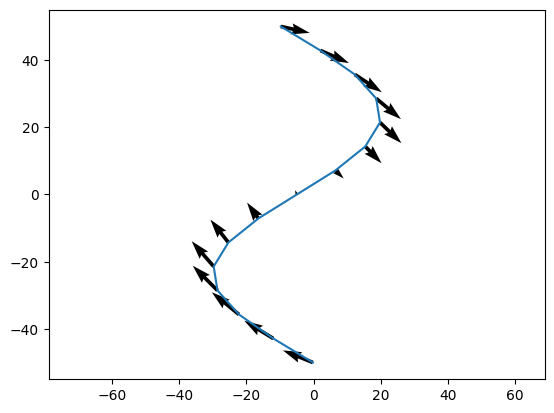

In [4]:
y_squ = np.linspace(-50, 50, 15)
x_squ = 25*np.sin(y_squ/15) - 5

plt.plot(x_squ, y_squ)

from scipy.interpolate import RegularGridInterpolator
interp_u = RegularGridInterpolator((y, x), u.T)
interp_v = RegularGridInterpolator((y, x), v.T)
points = np.vstack([y_squ, x_squ]).T
u_squ = interp_u(points)
v_squ = interp_v(points)

plt.quiver(x_squ, y_squ, u_squ, v_squ)
plt.axis('equal')


(np.float64(-66.47544906751365),
 np.float64(43.62203493163845),
 np.float64(-50.47038259709589),
 np.float64(42.18163219309889))

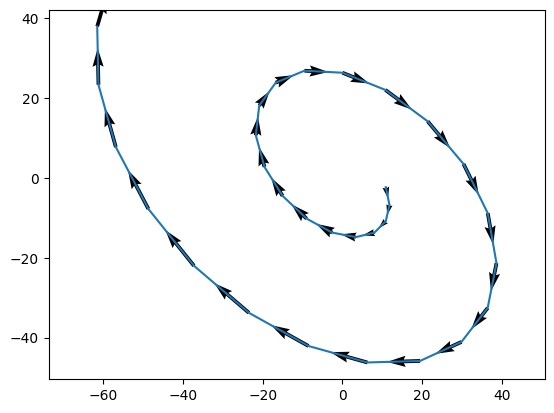

In [5]:
from scipy.interpolate import RegularGridInterpolator

fu = RegularGridInterpolator((x, y), u, bounds_error=False, fill_value=np.nan)
fv = RegularGridInterpolator((x, y), v, bounds_error=False, fill_value=np.nan)

N = 1
x_d = np.array([8.5356055])
y_d = np.array([1.8288253])

dt = 6
steps = 30

xs = [x_d.copy()]
ys = [y_d.copy()]

for _ in range(steps):
    pts = np.column_stack((x_d, y_d))                 
    ud = fu(pts)                                      
    vd = fv(pts)                                      
    oob = np.isnan(ud) | np.isnan(vd)
    if np.any(oob):
        x_d = np.clip(x_d, x.min(), x.max())
        y_d = np.clip(y_d, y.min(), y.max())
        ud = np.nan_to_num(ud, nan=0.0)
        vd = np.nan_to_num(vd, nan=0.0)
    x_d = x_d + ud*dt
    y_d = y_d + vd*dt
    xs.append(x_d.copy())
    ys.append(y_d.copy())
    
x_drif = np.squeeze(np.array(xs)[1:])
y_drif = np.squeeze(np.array(ys)[1:])

points = np.vstack([y_drif, x_drif]).T
u_drif = interp_u(points)
v_drif = interp_v(points)

plt.plot(x_drif, y_drif)
plt.quiver(x_drif, y_drif, u_drif, v_drif)
plt.axis('equal')


(np.float64(-27.5), np.float64(27.5), np.float64(-55.0), np.float64(55.0))

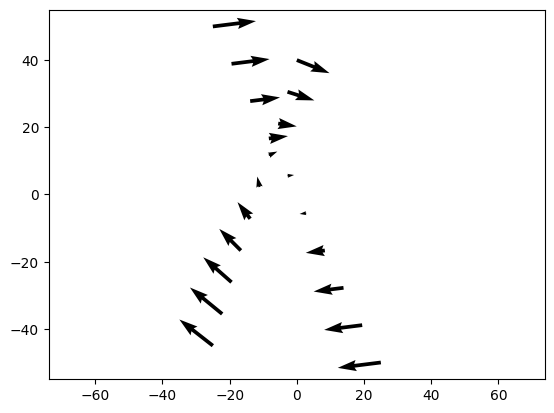

In [6]:
scaling = 5

x_l1 = np.linspace(-5*scaling, 0*scaling, 10)
y_l1 = np.linspace(-9*scaling, 8*scaling, 10)
points = np.vstack([y_l1, x_l1]).T
u_l1 = interp_u(points)
v_l1 = interp_v(points)
plt.quiver(x_l1, y_l1, u_l1, v_l1)

x_l2 = np.linspace(-5*scaling, 5*scaling, 10)
y_l2 = np.linspace(10*scaling, -10*scaling, 10)
points = np.vstack([y_l2, x_l2]).T
u_l2 = interp_u(points)
v_l2 = interp_v(points)
plt.quiver(x_l2, y_l2, u_l2, v_l2)

x_l = np.array(list(x_l1) + list(x_l2))
y_l = np.array(list(y_l1) + list(y_l2))
u_l = np.array(list(u_l1) + list(u_l2))
v_l = np.array(list(v_l1) + list(v_l2))

plt.axis('equal')


(np.float64(-54.0), np.float64(34.0), np.float64(-54.0), np.float64(34.0))

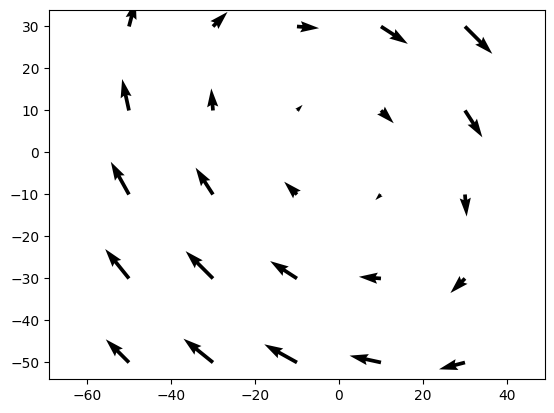

In [7]:
x_p = np.arange(-50, 50, 20)
y_p = np.arange(-50, 50, 20)
x_p, y_p = np.meshgrid(x_p, y_p)
x_p, y_p = x_p.flatten(), y_p.flatten()
points = np.vstack([y_p, x_p]).T
u_p = interp_u(points)
v_p = interp_v(points)
plt.quiver(x_p, y_p, u_p, v_p)
plt.axis('equal')


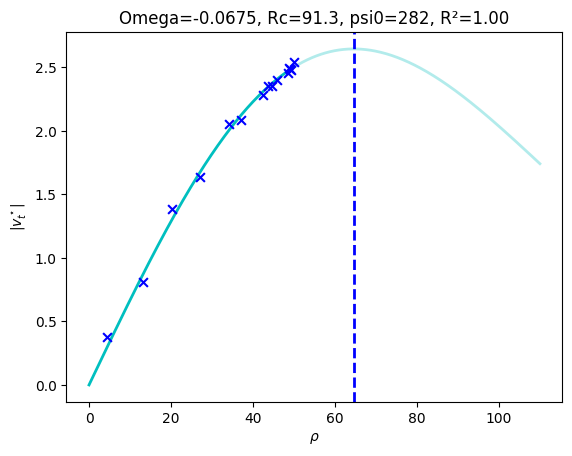

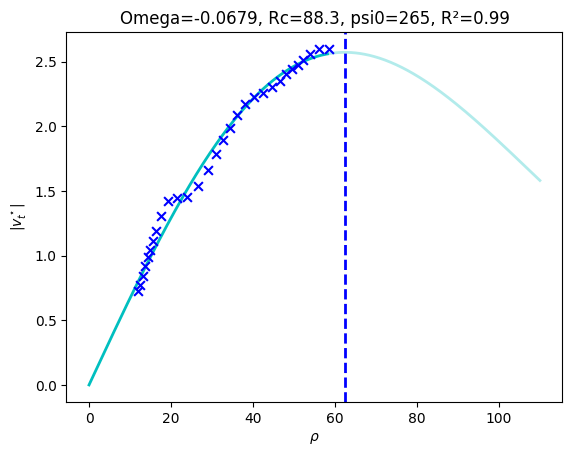

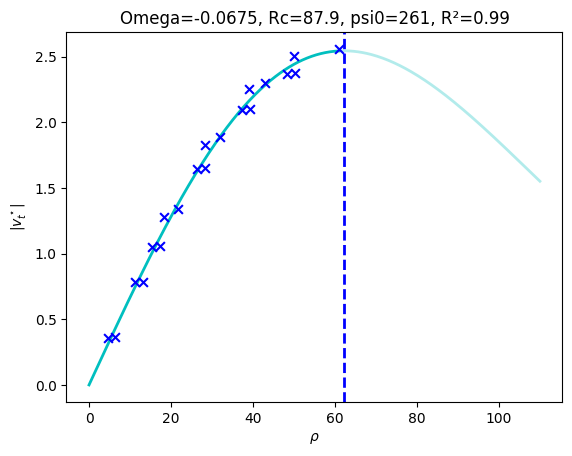

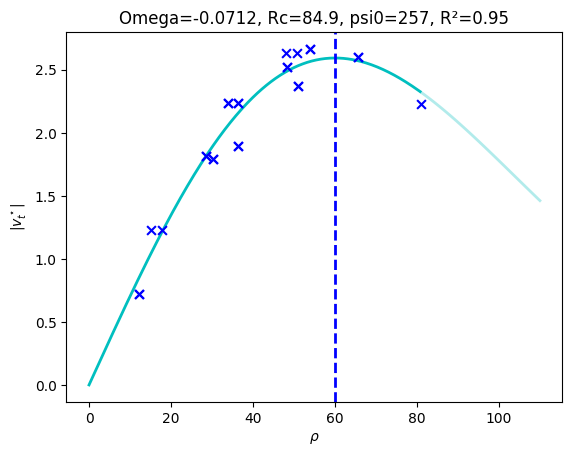

In [8]:
xc, yc, w, Q, Omega = latte(x_squ, y_squ, u_squ, v_squ)
df = psi_params(xc, yc, Q, x_squ, y_squ, u_squ, v_squ)
Rc, psi0, Omega = out_core_param_fit(df.rho2, df.Qr, df.vt, Omega0=Omega, plot=True)
df_res.loc[len(df_res)] = {'xc': xc, 'yc': yc, 'w': w*1e-3, 'q11': Q[0,0], 'q12': Q[1,0], 'q22': Q[1,1],
                        'Rc': Rc, 'psi0': psi0, 'Omega': Omega*1e-3}
df_squ = psi_params(xc, yc, Q, x_squ, y_squ, u_squ, v_squ)

xc, yc, w, Q, Omega = latte(x_drif, y_drif, u_drif, v_drif)
df = psi_params(xc, yc, Q, x_drif, y_drif, u_drif, v_drif)
Rc, psi0, Omega = out_core_param_fit(df.rho2, df.Qr, df.vt, Omega0=Omega, plot=True)
df_res.loc[len(df_res)] = {'xc': xc, 'yc': yc, 'w': w*1e-3, 'q11': Q[0,0], 'q12': Q[1,0], 'q22': Q[1,1],
                        'Rc': Rc, 'psi0': psi0, 'Omega': Omega*1e-3}
df_drif = psi_params(xc, yc, Q, x_drif, y_drif, u_drif, v_drif)

xc, yc, w, Q, Omega = latte(x_l, y_l, u_l, v_l)
df = psi_params(xc, yc, Q, x_l, y_l, u_l, v_l)
Rc, psi0, Omega = out_core_param_fit(df.rho2, df.Qr, df.vt, Omega0=Omega, plot=True)
df_res.loc[len(df_res)] = {'xc': xc, 'yc': yc, 'w': w*1e-3, 'q11': Q[0,0], 'q12': Q[1,0], 'q22': Q[1,1],
                        'Rc': Rc, 'psi0': psi0, 'Omega': Omega*1e-3}
df_l = psi_params(xc, yc, Q, x_l, y_l, u_l, v_l)

xc, yc, w, Q, Omega = latte(x_p, y_p, u_p, v_p)
df = psi_params(xc, yc, Q, x_p, y_p, u_p, v_p)
Rc, psi0, Omega = out_core_param_fit(df.rho2, df.Qr, df.vt, Omega0=Omega, plot=True)
df_res.loc[len(df_res)] = {'xc': xc, 'yc': yc, 'w': w*1e-3, 'q11': Q[0,0], 'q12': Q[1,0], 'q22': Q[1,1],
                        'Rc': Rc, 'psi0': psi0, 'Omega': Omega*1e-3}
df_p = psi_params(xc, yc, Q, x_p, y_p, u_p, v_p)


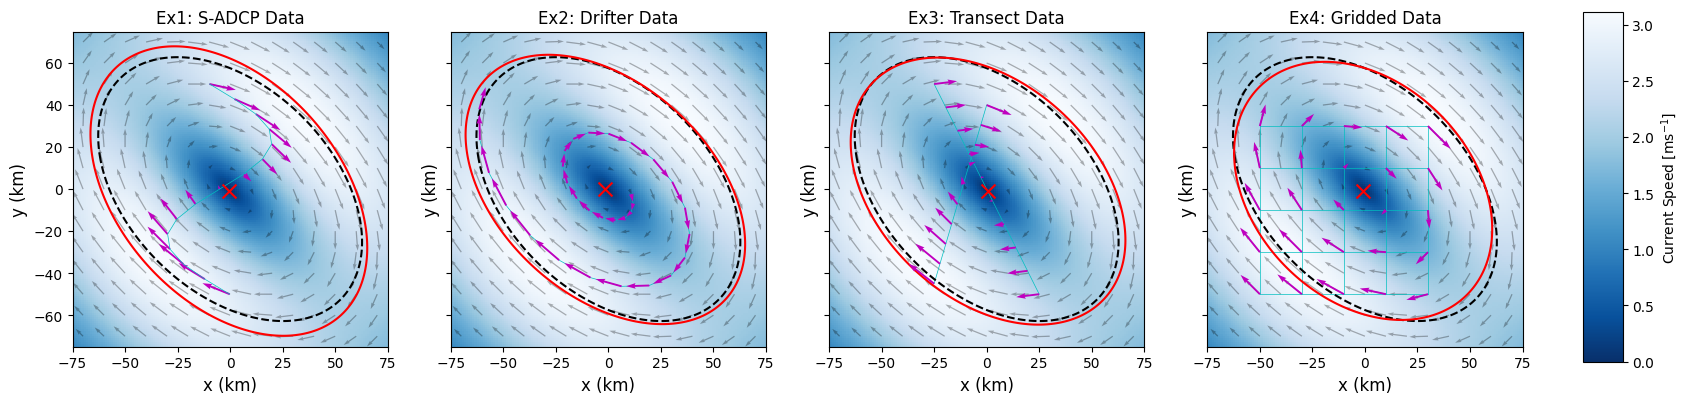

,xc,yc,w,q11,q12,q22,Rc,psi0,Omega
Control,0.000000,0.000000,-0.000151,1.091089,0.436436,1.091089,85.000000,250.000000,-0.000069
Ex1,-0.610966,-0.924386,-0.000116,1.137408,0.427534,1.039895,91.331041,281.617400,-0.000068
Ex2,-1.445990,-0.161871,-0.000114,1.054511,0.444784,1.135913,88.256970,264.531635,-0.000068
Ex2,0.666927,-0.949101,-0.000112,1.045108,0.394243,1.105558,87.909594,260.699800,-0.000067
Ex3,-0.840778,-0.840778,-0.000099,1.046659,0.309022,1.046659,84.896625,256.683408,-0.000071


In [9]:
clr = 'm'
scat_scale = .75

fig, axs = plt.subplots(1, 4, figsize=(20, 5), constrained_layout=False, sharey=True, sharex=True)

cmap = 'Blues_r'
spacing, scale, width = 10, 40, 0.004
wid = 1.5

# ---- plot background pcolor + quiver on each axis ----
for ax in axs:
    pc = ax.pcolor(x, y, np.hypot(u, v).T, cmap=cmap)
    ax.quiver(
        x[::spacing], y[::spacing],
        u[::spacing, ::spacing].T, v[::spacing, ::spacing].T,
        alpha=0.3, scale=scale, width=width, zorder=1
    )
    ax.set_aspect('equal', 'box')
    ax.set_xlim(-75, 75)
    ax.set_ylim(-75, 75)
    ax.set_xlabel('x (km)', fontsize=12)
    ax.set_ylabel('y (km)', fontsize=12)

# ---- Panel 1: Example S-ADCP Data ----
axs[0].plot(x_squ, y_squ, 'c', linewidth=.5)
axs[0].quiver(x_squ, y_squ, u_squ, v_squ, scale=scale*scat_scale, width=width*wid, color=clr)
axs[0].contour(X, Y, rho2, levels=[df_res.iloc[0].Rc**2/2],
                     colors='k', linestyles='--')
data = df_res.iloc[1]
dx_ell, dy_ell = X - data.xc, Y - data.yc
rho2_ell = data.q11*dx_ell**2 + 2*data.q12*dx_ell*dy_ell + data.q22*dy_ell**2
axs[0].contour(X, Y, rho2_ell, levels=[data.Rc**2/2], colors='r')
axs[0].scatter(data.xc, data.yc, marker='x', s=100, color='r', zorder=10)
axs[0].set_title('Ex1: S-ADCP Data')

# ---- Panel 2: Example Drifter Data ----
axs[1].plot(x_drif, y_drif, 'c', linewidth=.5)
axs[1].quiver(x_drif, y_drif, u_drif, v_drif, scale=scale*scat_scale, width=width*wid, color=clr, zorder=3)
axs[1].contour(X, Y, rho2, levels=[df_res.iloc[0].Rc**2/2],
                     colors='k', linestyles='--')
data = df_res.iloc[2]
dx_ell, dy_ell = X - data.xc, Y - data.yc
rho2_ell = data.q11*dx_ell**2 + 2*data.q12*dx_ell*dy_ell + data.q22*dy_ell**2
axs[1].contour(X, Y, rho2_ell, levels=[data.Rc**2/2], colors='r')
axs[1].scatter(data.xc, data.yc, marker='x', s=100, color='r', zorder=10)
axs[1].set_title('Ex2: Drifter Data')

# ---- Panel 3: Example Transect Data ----
axs[2].plot(x_l1, y_l1, 'c', linewidth=.5)
axs[2].plot(x_l2, y_l2, 'c', linewidth=.5)
axs[2].quiver(x_l1, y_l1, u_l1, v_l1, scale=scale*scat_scale, width=width*wid, color=clr, zorder=3)
axs[2].quiver(x_l2, y_l2, u_l2, v_l2, scale=scale*scat_scale, width=width*wid, color=clr, zorder=3)
axs[2].contour(X, Y, rho2, levels=[df_res.iloc[0].Rc**2/2],
                     colors='k', linestyles='--')
data = df_res.iloc[3]
dx_ell, dy_ell = X - data.xc, Y - data.yc
rho2_ell = data.q11*dx_ell**2 + 2*data.q12*dx_ell*dy_ell + data.q22*dy_ell**2
axs[2].contour(X, Y, rho2_ell, levels=[data.Rc**2/2], colors='r')
axs[2].scatter(data.xc, data.yc, marker='x', s=100, color='r', zorder=10)
axs[2].set_title('Ex3: Transect Data')

# ---- Panel 4: Example Gridded Data ----
# horizontal transects
for i in range(0, 25, 5):
    axs[3].plot([x_p[i], x_p[i+4]], [y_p[i], y_p[i+4]], 'c', linewidth=.5)
# vertical transects
for i in range(5):
    axs[3].plot([x_p[i], x_p[i+20]], [y_p[i], y_p[i+20]], 'c', linewidth=.5)
axs[3].quiver(x_p, y_p, u_p, v_p, scale=scale*scat_scale, width=width*wid, color=clr, zorder=3)
axs[3].contour(X, Y, rho2, levels=[df_res.iloc[0].Rc**2/2],
                     colors='k', linestyles='--')
data = df_res.iloc[4]
dx_ell, dy_ell = X - data.xc, Y - data.yc
rho2_ell = data.q11*dx_ell**2 + 2*data.q12*dx_ell*dy_ell + data.q22*dy_ell**2
axs[3].contour(X, Y, rho2_ell, levels=[data.Rc**2/2], colors='r')
axs[3].scatter(data.xc, data.yc, marker='x', s=100, color='r', zorder=10)
axs[3].set_title('Ex4: Gridded Data')

# ---- now place one colorbar to the right of the entire figure ----
# leave room on the right
fig.subplots_adjust(right=0.85)

# [left, bottom, width, height] in figure coords
cbar_ax = fig.add_axes([0.88, 0.15, 0.02, 0.7])
fig.colorbar(pc, cax=cbar_ax, orientation='vertical', label=r'Current Speed [ms$^{-1}$]')

plt.show()
df_res.index = ['Control', 'Ex1', 'Ex2', 'Ex2', 'Ex3']
df_res


In [10]:
def fit_psi_params(rho2, Qr, vt, A0=None, Rc0=None, plot=False, ax=None,
                   maxfev=10000, Rc_max=1e5, r2_flag=False,
                   rho_plot_max=None, n_curve=400, fit_label='', markersize=50, clr='b', lw=3):
    from scipy.optimize import curve_fit

    import matplotlib.colors as mcolors

    def color_chg(color, factor=.8):
        rgb = mcolors.to_rgb(color)
        return tuple(max(0, c * factor) for c in rgb)

    # def color_chg(color, factor=1.2):
    #     rgb = mcolors.to_rgb(color)
    #     return tuple(min(1, c * factor) for c in rgb)

    d = pd.DataFrame({'rho2': rho2, 'Qr': Qr, 'vt': vt})
    m = (np.isfinite(d.rho2) & np.isfinite(d.vt) & np.isfinite(d.Qr) & (d.rho2 >= 0) & (d.Qr != 0))
    if not np.any(m):
        raise ValueError("No valid rows after masking.")
    rho2 = d.rho2.values[m]
    vt   = d.vt.values[m]
    Qr   = d.Qr.values[m]

    vt = vt * (np.sqrt(rho2) / Qr)

    def vt_model(rho2_, A, Rc):
        return 2.0 * A * np.sqrt(rho2_) * np.exp(-rho2_ / (Rc**2))

    i = np.nanargmax(np.abs(vt))
    rho_max = np.sqrt(rho2[i])
    if Rc0 is None:
        Rc0 = max(rho_max * np.sqrt(2.0), 1e-6)

    denom = 2.0 * np.sqrt(rho2) * np.exp(-rho2 / (Rc0**2))
    ok = np.abs(denom) > 0
    if A0 is None:
        A0 = np.nanmedian(vt[ok] / denom[ok]) if np.any(ok) else 0.0
    if not np.isfinite(A0):
        A0 = 0.0

    popt, _ = curve_fit(vt_model, rho2, vt, p0=[A0, Rc0],
                        bounds=([-np.inf, 1e-8], [np.inf, np.inf]),
                        maxfev=maxfev)
    A_opt, Rc_opt = popt
    if Rc_opt > Rc_max:
        A_opt, Rc_opt = A0, Rc0

    psi0_opt = -A_opt * Rc_opt**2

    vt_fit = vt_model(rho2, *popt)
    ss_res = np.sum((vt - vt_fit)**2)
    ss_tot = np.sum((vt - np.mean(vt))**2)
    r2 = 1 - ss_res / ss_tot if ss_tot != 0 else np.nan

    if plot:
        r_data = np.sqrt(rho2)
        if rho_plot_max is None:
            rho_plot_max = float(np.nanmax(r_data)) if r_data.size else Rc_opt
        r_data_max = float(np.nanmax(r_data))
        r_grid = np.linspace(0.0, rho_plot_max, n_curve)
        vt_grid = vt_model(r_grid**2, A_opt, Rc_opt)


        psi0 = 250.0
        Rc = 85.0
        A = - psi0 / Rc**2
        vt_true = vt_model(r_grid**2, A, Rc)

        if ax is None:
            _, ax = plt.subplots()
        ax.scatter(r_data, np.abs(vt), s=markersize, zorder=1, color=color_chg(clr), marker='x')
        mask = r_grid <= r_data_max
        ax.plot(r_grid[mask], np.abs(vt_grid[mask]), label=fit_label, lw=lw, zorder=0, color=clr)
        ax.plot(r_grid[~mask], np.abs(vt_grid[~mask]), label=fit_label, lw=lw, zorder=0, color=clr, alpha=.3)

        # ax.plot(r_grid, np.abs(vt_true), label=fit_label, lw=1, zorder=-1, color='k')
        
        ax.axvline(x=Rc_opt/np.sqrt(2), ls='--', label=r'$\rho_{\max}$', lw=2, color=clr)
        ax.set_xlabel(r'$\rho$')
        ax.set_ylabel(r'$|v_t^\star|$')
        # ax.legend()
        ax.set_title(f'Best Fit: A={A_opt:.4g}, Rc={Rc_opt:.4g}, psi0={psi0_opt:.4g}, R²={r2:.2f}')

    return (Rc_opt, psi0_opt, A_opt, r2) if r2_flag else (Rc_opt, psi0_opt, A_opt)
    

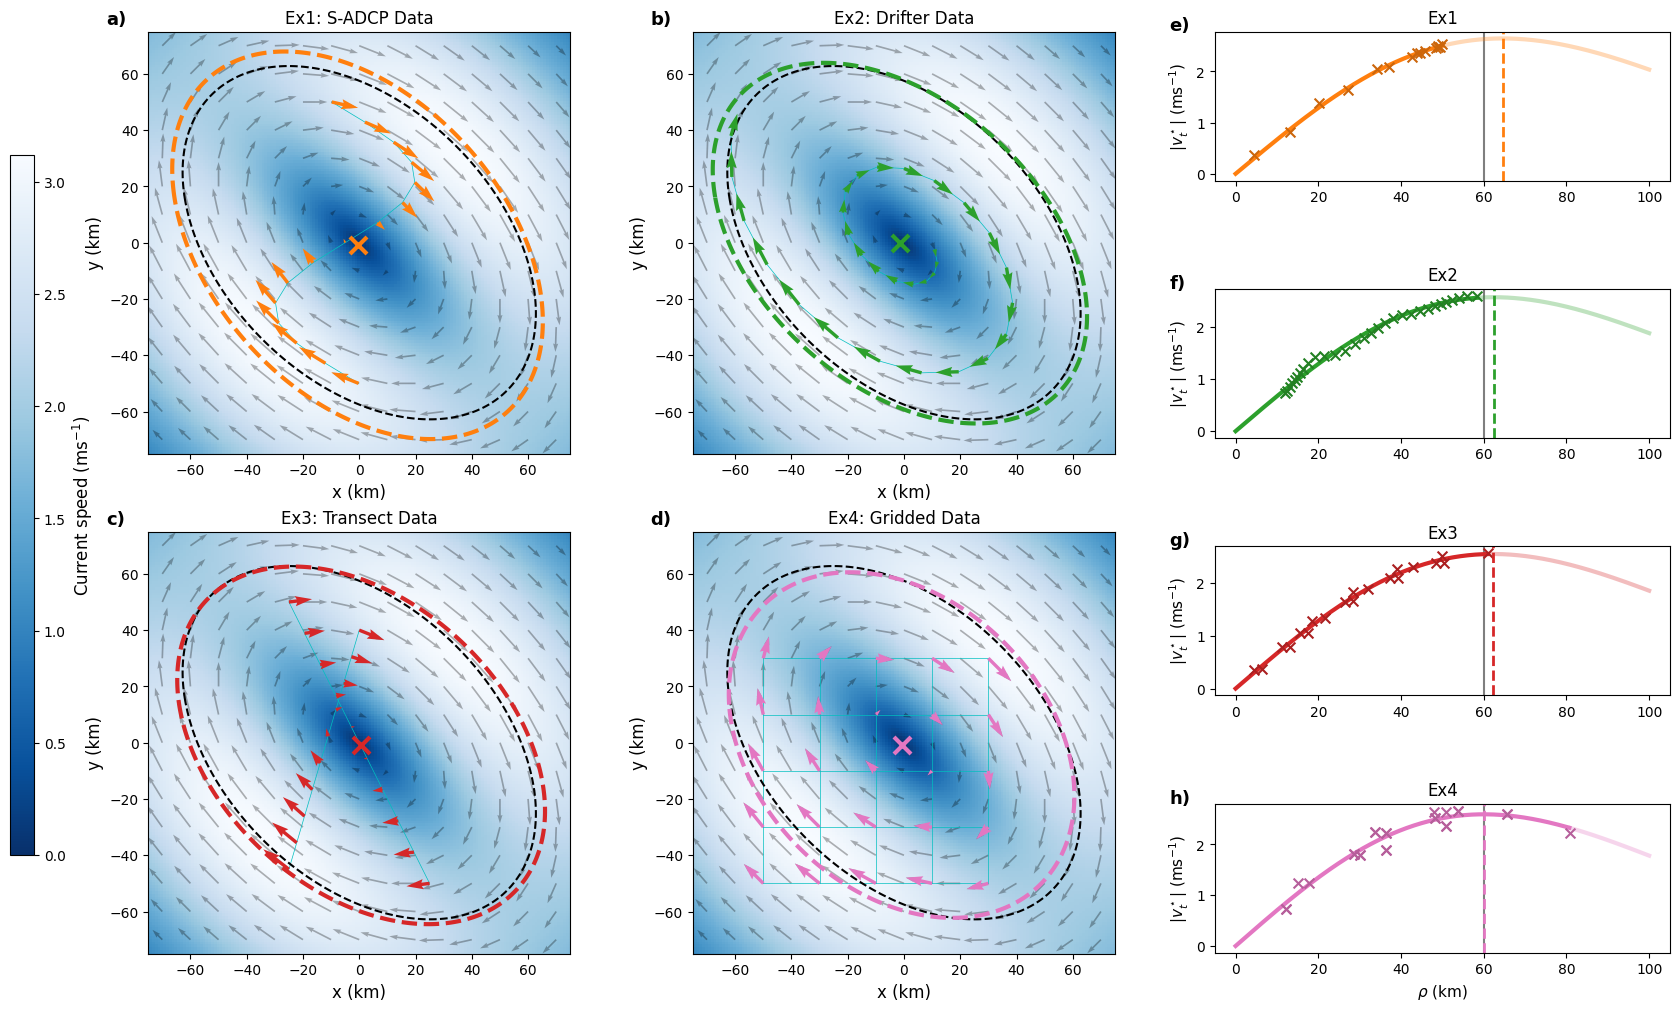

In [11]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import matplotlib.colors as mcolors

clr = 'b'
scat_scale = 1
cmap = 'Blues_r'
spacing, scale, width = 10, 40, 0.004
wid = 2
lw = 3

tab10 = plt.get_cmap('tab10').colors

def color_chg(color, factor=.6):
    rgb = mcolors.to_rgb(color)
    return tuple(max(0, c * factor) for c in rgb)

# --- overall layout: 2x3 grid ---
fig = plt.figure(figsize=(16, 10), constrained_layout=True)
gs = gridspec.GridSpec(2, 3, figure=fig, width_ratios=[1, 1, 1], wspace=0, hspace=0)

# ---- create 4 example panels ----
axs = [fig.add_subplot(gs[0,0]), fig.add_subplot(gs[0,1]),
       fig.add_subplot(gs[1,0]), fig.add_subplot(gs[1,1])]

# ---- background field ----
for ax in axs:
    pc = ax.pcolor(x, y, np.hypot(u, v).T, cmap=cmap)
    ax.quiver(x[::spacing], y[::spacing],
              u[::spacing, ::spacing].T, v[::spacing, ::spacing].T,
              alpha=0.3, scale=scale, width=width, zorder=1)
    ax.set_aspect('equal', 'box')
    ax.set_xlim(-75, 75)
    ax.set_ylim(-75, 75)
    ax.set_xlabel('x (km)', fontsize=12)
    ax.set_ylabel('y (km)', fontsize=12)

# ---- Panel 1: Example S-ADCP Data ----
axs[0].plot(x_squ, y_squ, 'c', linewidth=.5, zorder=2)
axs[0].quiver(x_squ, y_squ, u_squ, v_squ, scale=scale*scat_scale, width=width*wid, color=tab10[1], zorder=3)
axs[0].contour(X, Y, rho2, levels=[df_res.iloc[0].Rc**2/2], colors='k', linestyles='--')
data = df_res.iloc[1]
dx_ell, dy_ell = X - data.xc, Y - data.yc
rho2_ell = data.q11*dx_ell**2 + 2*data.q12*dx_ell*dy_ell + data.q22*dy_ell**2
axs[0].contour(X, Y, rho2_ell, levels=[data.Rc**2/2], colors=[tab10[1]], linewidths=[lw], linestyles='--')
axs[0].scatter(data.xc, data.yc, marker='x', s=150, color=tab10[1], zorder=10, linewidths=3)
axs[0].set_title('Ex1: S-ADCP Data')
axs[0].text(-.1, 1.05, 'a)', transform=axs[0].transAxes, fontsize=13, fontweight='bold', va='top', ha='left')

# ---- Panel 2: Example Drifter Data ----
axs[1].plot(x_drif, y_drif, 'c', linewidth=.5, zorder=2)
axs[1].quiver(x_drif, y_drif, u_drif, v_drif, scale=scale*scat_scale, width=width*wid, color=tab10[2], zorder=3)
axs[1].contour(X, Y, rho2, levels=[df_res.iloc[0].Rc**2/2], colors='k', linestyles='--')
data = df_res.iloc[2]
dx_ell, dy_ell = X - data.xc, Y - data.yc
rho2_ell = data.q11*dx_ell**2 + 2*data.q12*dx_ell*dy_ell + data.q22*dy_ell**2
axs[1].contour(X, Y, rho2_ell, levels=[data.Rc**2/2], colors=[tab10[2]], linewidths=[lw], linestyles='--')
axs[1].scatter(data.xc, data.yc, marker='x', s=150, color=tab10[2], zorder=10, linewidths=3)
axs[1].set_title('Ex2: Drifter Data')
axs[1].text(-.1, 1.05, 'b)', transform=axs[1].transAxes, fontsize=13, fontweight='bold', va='top', ha='left')

# ---- Panel 3: Example Transect Data ----
axs[2].plot(x_l1, y_l1, 'c', linewidth=.5, zorder=2)
axs[2].plot(x_l2, y_l2, 'c', linewidth=.5, zorder=2)
axs[2].quiver(x_l1, y_l1, u_l1, v_l1, scale=scale*scat_scale, width=width*wid, color=tab10[3], zorder=3)
axs[2].quiver(x_l2, y_l2, u_l2, v_l2, scale=scale*scat_scale, width=width*wid, color=tab10[3], zorder=3)
axs[2].contour(X, Y, rho2, levels=[df_res.iloc[0].Rc**2/2], colors='k', linestyles='--')
data = df_res.iloc[3]
dx_ell, dy_ell = X - data.xc, Y - data.yc
rho2_ell = data.q11*dx_ell**2 + 2*data.q12*dx_ell*dy_ell + data.q22*dy_ell**2
axs[2].contour(X, Y, rho2_ell, levels=[data.Rc**2/2], colors=[tab10[3]], linewidths=[lw], linestyles='--')
axs[2].scatter(data.xc, data.yc, marker='x', s=150, color=tab10[3], zorder=10, linewidths=3)
axs[2].set_title('Ex3: Transect Data')
axs[2].text(-.1, 1.05, 'c)', transform=axs[2].transAxes, fontsize=13, fontweight='bold', va='top', ha='left')

# ---- Panel 4: Example Gridded Data ----
for i in range(0, 25, 5):
    axs[3].plot([x_p[i], x_p[i+4]], [y_p[i], y_p[i+4]], 'c', linewidth=.5, zorder=2)
for i in range(5):
    axs[3].plot([x_p[i], x_p[i+20]], [y_p[i], y_p[i+20]], 'c', linewidth=.5, zorder=2)
axs[3].quiver(x_p, y_p, u_p, v_p, scale=scale*scat_scale, width=width*wid, color=tab10[6], zorder=3)
axs[3].contour(X, Y, rho2, levels=[df_res.iloc[0].Rc**2/2], colors='k', linestyles='--')
data = df_res.iloc[4]
dx_ell, dy_ell = X - data.xc, Y - data.yc
rho2_ell = data.q11*dx_ell**2 + 2*data.q12*dx_ell*dy_ell + data.q22*dy_ell**2
axs[3].contour(X, Y, rho2_ell, levels=[data.Rc**2/2], colors=[tab10[6]], linewidths=[lw], linestyles='--')
axs[3].scatter(data.xc, data.yc, marker='x', s=150, color=tab10[6], zorder=10, linewidths=3)
axs[3].set_title('Ex4: Gridded Data')
axs[3].text(-.1, 1.05, 'd)', transform=axs[3].transAxes, fontsize=13, fontweight='bold', va='top', ha='left')

cax = fig.add_axes([-0.04, 0.15, 0.015, 0.7])
cb = fig.colorbar(pc, cax=cax, orientation='vertical')
cb.set_label(r'Current speed (ms$^{-1}$)', fontsize=12)

# ---- right-side: 4x1 stacked fits ----
right = gridspec.GridSpecFromSubplotSpec(4, 1, subplot_spec=gs[:, 2], hspace=0.25)
ax_fits = [fig.add_subplot(right[i, 0]) for i in range(4)]

rho_plot_max = 100
lw = 3
Rc = df_res.iloc[0].Rc

fit_psi_params(df_squ.rho2, df_squ.Qr, df_squ.vt, ax=ax_fits[0], plot=True, rho_plot_max=rho_plot_max, fit_label='Ex1', clr=tab10[1], lw=lw)
ax_fits[0].axvline(Rc/np.sqrt(2), color='k', zorder=-1, alpha=.5)
ax_fits[0].set_title('Ex1')
ax_fits[0].set_xlabel('')
ax_fits[0].set_ylabel(r'$|v_t^\star|$ (ms$^{-1}$)', fontsize=11)
ax_fits[0].text(-.1, 1.1, 'e)', transform=ax_fits[0].transAxes, fontsize=13, fontweight='bold', va='top', ha='left')

fit_psi_params(df_drif.rho2, df_drif.Qr, df_drif.vt, ax=ax_fits[1], plot=True, rho_plot_max=rho_plot_max, fit_label='Ex2', clr=tab10[2], lw=lw)
ax_fits[1].axvline(Rc/np.sqrt(2), color='k', zorder=-1, alpha=.5)
ax_fits[1].set_title('Ex2')
ax_fits[1].set_xlabel('')
ax_fits[1].set_ylabel(r'$|v_t^\star|$ (ms$^{-1}$)', fontsize=11)
ax_fits[1].text(-.1, 1.1, 'f)', transform=ax_fits[1].transAxes, fontsize=13, fontweight='bold', va='top', ha='left')

fit_psi_params(df_l.rho2, df_l.Qr, df_l.vt, ax=ax_fits[2], plot=True, rho_plot_max=rho_plot_max, fit_label='Ex3', clr=tab10[3], lw=lw)
ax_fits[2].axvline(Rc/np.sqrt(2), color='k', zorder=-1, alpha=.5)
ax_fits[2].set_title('Ex3')
ax_fits[2].set_xlabel('')
ax_fits[2].set_ylabel(r'$|v_t^\star|$ (ms$^{-1}$)', fontsize=11)
ax_fits[2].text(-.1, 1.1, 'g)', transform=ax_fits[2].transAxes, fontsize=13, fontweight='bold', va='top', ha='left')

fit_psi_params(df_p.rho2, df_p.Qr, df_p.vt, ax=ax_fits[3], plot=True, rho_plot_max=rho_plot_max, fit_label='Ex4', clr=tab10[6], lw=lw)
ax_fits[3].axvline(Rc/np.sqrt(2), color='k', zorder=-1, alpha=.5)
ax_fits[3].set_title('Ex4')
ax_fits[3].set_xlabel(r'$\rho$ (km)', fontsize=11)
ax_fits[3].set_ylabel(r'$|v_t^\star|$ (ms$^{-1}$)', fontsize=11)
ax_fits[3].text(-.1, 1.1, 'h)', transform=ax_fits[3].transAxes, fontsize=13, fontweight='bold', va='top', ha='left')

plt.show()


In [13]:
df_paper = df_res.copy()
df_paper['alpha'] = [axis_ratio_from_Q(np.array([[q11, q12], [q12, q22]])) for (q11, q12, q22) in zip(df_paper.q11, df_paper.q12, df_paper.q22)]
df_paper = df_paper.drop(columns=['q11', 'q12', 'q22'])
df_paper


,xc,yc,w,Rc,psi0,Omega,alpha
Control,0.000000,0.000000,-0.000151,85.000000,250.000000,-0.000069,1.527525
Ex1,-0.610966,-0.924386,-0.000116,91.331041,281.617400,-0.000068,1.518957
Ex2,-1.445990,-0.161871,-0.000114,88.256970,264.531635,-0.000068,1.541855
Ex2,0.666927,-0.949101,-0.000112,87.909594,260.699800,-0.000067,1.470733
Ex3,-0.840778,-0.840778,-0.000099,84.896625,256.683408,-0.000071,1.355681


In [14]:
df_err = (df_paper - df_paper.iloc[0]).abs().iloc[1:]
df_err.index = ['Ex1 Err', 'Ex2 Err', 'Ex3 Err', 'Ex4 Err']
df_err


,xc,yc,w,Rc,psi0,Omega,alpha
Ex1 Err,0.610966,0.924386,0.000035,6.331041,31.617400,0.000002,0.008568
Ex2 Err,1.445990,0.161871,0.000037,3.256970,14.531635,0.000001,0.014329
Ex3 Err,0.666927,0.949101,0.000039,2.909594,10.699800,0.000002,0.056792
Ex4 Err,0.840778,0.840778,0.000052,0.103375,6.683408,0.000002,0.171844


In [ ]:
dx = (X[1,0] - X[0,0])*1e3
dy = (Y[0,1] - Y[0,0])*1e3

dv_dx = np.gradient(v, dx, axis=0)
du_dy = np.gradient(u, dy, axis=1)

zeta = dv_dx - du_dy
plt.pcolor(X, Y, zeta)
plt.colorbar()
clrs =['r', 'm', 'b', 'w', 'orange']
for i, clr in enumerate(clrs):
    plt.contour(X, Y, zeta, levels=[df_res.iloc[i].w], colors=clr) 
# plt.contour(X, Y, zeta, levels=[-0.07391396167122072*1e-3], colors='r') 


In [ ]:
df_res.iloc[0].w
